In [2]:
import kagglehub
path = kagglehub.dataset_download("orvile/wesad-wearable-stress-affect-detection-dataset")
print("Path to dataset files:", path)

100%|██████████| 2.43G/2.43G [01:04<00:00, 40.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/versions/1


In [3]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files[:5]:
            print(f'{indent}  {f}')

1/
  WESAD/
    wesad_readme.pdf
    S16/
      S16_respiban.txt
      S16.pkl
      S16_readme.txt
      S16_quest.csv
      S16_E4_Data/
    S13/
      S13_respiban.txt
      S13.pkl
      S13_readme.txt
      S13_quest.csv
      S13_E4_Data/
    S3/
      S3_respiban.txt
      S3_readme.txt
      S3.pkl
      S3_quest.csv
      S3_E4_Data/
    S4/
      S4_quest.csv
      S4_readme.txt
      S4.pkl
      S4_respiban.txt
      S4_E4_Data/
    S15/
      S15_quest.csv
      S15_readme.txt
      S15.pkl
      S15_respiban.txt
      S15_E4_Data/
    S2/
      S2_respiban.txt
      S2_readme.txt
      S2.pkl
      S2_quest.csv
      S2_E4_Data/
    S5/
      S5_quest.csv
      S5_readme.txt
      S5.pkl
      S5_respiban.txt
      S5_E4_Data/
    S6/
      S6_readme.txt
      S6_quest.csv
      S6_respiban.txt
      S6.pkl
      S6_E4_Data/
    S10/
      S10.pkl
      S10_readme.txt
      S10_respiban.txt
      S10_quest.csv
      S10_E4_Data/
    S8/
      S8_respiban.txt
      S8.pkl


In [5]:
import pickle
import numpy as np

subject_path = f'{path}/WESAD/S2/S2.pkl'

with open(subject_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print(data.keys())
print(data['signal']['chest'].keys())
print(np.unique(data['label'], return_counts=True))

dict_keys(['signal', 'label', 'subject'])
dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
(array([0, 1, 2, 3, 4, 6, 7], dtype=int32), array([2142701,  800800,  430500,  253400,  537599,   45500,   44800]))


In [6]:
import pandas as pd

def extract_features(signal_window):
    return {
        'mean': np.mean(signal_window),
        'std': np.std(signal_window),
        'min': np.min(signal_window),
        'max': np.max(signal_window),
        'range': np.max(signal_window) - np.min(signal_window)
    }

def process_subject(subject_path, subject_id, window_sec=60, fs=700):
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    eda = data['signal']['chest']['EDA'].flatten()
    ecg = data['signal']['chest']['ECG'].flatten()
    temp = data['signal']['chest']['Temp'].flatten()
    resp = data['signal']['chest']['Resp'].flatten()
    labels = data['label']

    window_size = window_sec * fs
    n_windows = len(labels) // window_size

    rows = []
    for i in range(n_windows):
        start, end = i * window_size, (i + 1) * window_size
        window_labels = labels[start:end]
        majority_label = np.bincount(window_labels).argmax()
        if majority_label not in [1, 2, 3]:
            continue

        row = {'subject': subject_id, 'label': majority_label}
        for name, sig in [('eda', eda), ('ecg', ecg), ('temp', temp), ('resp', resp)]:
            feats = extract_features(sig[start:end])
            row.update({f'{name}_{k}': v for k, v in feats.items()})
        rows.append(row)

    return pd.DataFrame(rows)

subject_ids = [f'S{i}' for i in range(2, 18) if i != 12]
all_data = []

for sid in subject_ids:
    subj_path = f'{path}/WESAD/{sid}/{sid}.pkl'
    try:
        df_subj = process_subject(subj_path, sid)
        all_data.append(df_subj)
        print(f"{sid}: {len(df_subj)} windows")
    except FileNotFoundError:
        print(f"{sid}: not found, skipping")

df = pd.concat(all_data, ignore_index=True)
df.head()

S2: 35 windows
S3: 37 windows
S4: 36 windows
S5: 37 windows
S6: 36 windows
S7: 35 windows
S8: 36 windows
S9: 37 windows
S10: 37 windows
S11: 38 windows
S13: 37 windows
S14: 37 windows
S15: 36 windows
S16: 36 windows
S17: 37 windows


,subject,label,eda_mean,eda_std,eda_min,eda_max,eda_range,ecg_mean,ecg_std,ecg_min,...,temp_mean,temp_std,temp_min,temp_max,temp_range,resp_mean,resp_std,resp_min,resp_max,resp_range
0,S2,1,5.037455,0.302370,4.555511,5.957413,1.401901,0.001466,0.136763,-0.435883,...,29.167696,0.060271,29.011780,29.426208,0.414429,-0.041239,2.873152,-8.805847,6.742859,15.548706
1,S2,1,4.186873,0.230645,3.771591,4.671478,0.899887,0.000986,0.153720,-0.302902,...,28.885605,0.081293,28.727814,29.207275,0.479462,0.061072,1.595619,-3.147888,3.730774,6.878662
2,S2,1,3.547485,0.160775,3.255463,3.919220,0.663757,0.001455,0.182025,-1.499405,...,28.798117,0.037777,28.679108,28.988800,0.309692,0.033488,1.885184,-6.646729,5.216980,11.863708
3,S2,1,3.082894,0.161033,2.783203,3.411484,0.628281,0.001022,0.146379,-0.404984,...,28.753807,0.063520,28.584656,29.023285,0.438629,0.073635,1.537771,-2.944946,4.554749,7.499695
4,S2,1,2.623016,0.108412,2.189255,2.878571,0.689316,0.001122,0.144752,-0.272415,...,28.573872,0.041704,28.447449,28.820953,0.373505,0.062645,1.441556,-3.240967,3.205872,6.446838


In [7]:
import pandas as pd

def extract_features(signal_window):
    return {
        'mean': np.mean(signal_window),
        'std': np.std(signal_window),
        'min': np.min(signal_window),
        'max': np.max(signal_window),
        'range': np.max(signal_window) - np.min(signal_window)
    }

def process_subject(subject_path, subject_id, window_sec=60, fs=700):
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    eda = data['signal']['chest']['EDA'].flatten()
    ecg = data['signal']['chest']['ECG'].flatten()
    temp = data['signal']['chest']['Temp'].flatten()
    resp = data['signal']['chest']['Resp'].flatten()
    labels = data['label']

    window_size = window_sec * fs
    n_windows = len(labels) // window_size

    rows = []
    for i in range(n_windows):
        start, end = i * window_size, (i + 1) * window_size
        window_labels = labels[start:end]
        majority_label = np.bincount(window_labels).argmax()
        if majority_label not in [1, 2, 3]:
            continue

        row = {'subject': subject_id, 'label': majority_label}
        for name, sig in [('eda', eda), ('ecg', ecg), ('temp', temp), ('resp', resp)]:
            feats = extract_features(sig[start:end])
            row.update({f'{name}_{k}': v for k, v in feats.items()})
        rows.append(row)

    return pd.DataFrame(rows)

subject_ids = [f'S{i}' for i in range(2, 18) if i != 12]
all_data = []

for sid in subject_ids:
    subj_path = f'{path}/WESAD/{sid}/{sid}.pkl'
    try:
        df_subj = process_subject(subj_path, sid)
        all_data.append(df_subj)
        print(f"{sid}: {len(df_subj)} windows")
    except FileNotFoundError:
        print(f"{sid}: not found, skipping")

df = pd.concat(all_data, ignore_index=True)
df.head()

S2: 35 windows
S3: 37 windows
S4: 36 windows
S5: 37 windows
S6: 36 windows
S7: 35 windows
S8: 36 windows
S9: 37 windows
S10: 37 windows
S11: 38 windows
S13: 37 windows
S14: 37 windows
S15: 36 windows
S16: 36 windows
S17: 37 windows


,subject,label,eda_mean,eda_std,eda_min,eda_max,eda_range,ecg_mean,ecg_std,ecg_min,...,temp_mean,temp_std,temp_min,temp_max,temp_range,resp_mean,resp_std,resp_min,resp_max,resp_range
0,S2,1,5.037455,0.302370,4.555511,5.957413,1.401901,0.001466,0.136763,-0.435883,...,29.167696,0.060271,29.011780,29.426208,0.414429,-0.041239,2.873152,-8.805847,6.742859,15.548706
1,S2,1,4.186873,0.230645,3.771591,4.671478,0.899887,0.000986,0.153720,-0.302902,...,28.885605,0.081293,28.727814,29.207275,0.479462,0.061072,1.595619,-3.147888,3.730774,6.878662
2,S2,1,3.547485,0.160775,3.255463,3.919220,0.663757,0.001455,0.182025,-1.499405,...,28.798117,0.037777,28.679108,28.988800,0.309692,0.033488,1.885184,-6.646729,5.216980,11.863708
3,S2,1,3.082894,0.161033,2.783203,3.411484,0.628281,0.001022,0.146379,-0.404984,...,28.753807,0.063520,28.584656,29.023285,0.438629,0.073635,1.537771,-2.944946,4.554749,7.499695
4,S2,1,2.623016,0.108412,2.189255,2.878571,0.689316,0.001122,0.144752,-0.272415,...,28.573872,0.041704,28.447449,28.820953,0.373505,0.062645,1.441556,-3.240967,3.205872,6.446838


              precision    recall  f1-score   support

    Baseline       0.87      0.99      0.92        73
      Stress       0.95      1.00      0.98        41
   Amusement       1.00      0.48      0.65        23

    accuracy                           0.91       137
   macro avg       0.94      0.82      0.85       137
weighted avg       0.92      0.91      0.89       137



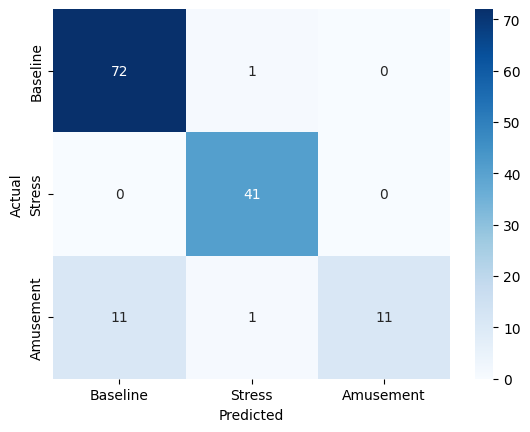

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = [c for c in df.columns if c not in ['subject', 'label']]
X = df[feature_cols]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Baseline', 'Stress', 'Amusement']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baseline', 'Stress', 'Amusement'],
            yticklabels=['Baseline', 'Stress', 'Amusement'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [9]:
from sklearn.inspection import permutation_importance

result = permutation_importance(clf, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1)
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': result.importances_mean
}).sort_values('importance_mean', ascending=False)

print(importance_df.head(10))

       feature  importance_mean
6      ecg_std         0.066180
1      eda_std         0.029684
16    resp_std         0.018978
4    eda_range         0.017518
2      eda_min         0.016545
14  temp_range         0.014112
12    temp_min         0.010706
3      eda_max         0.007299
10   temp_mean         0.007299
13    temp_max         0.007299


In [10]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score

logo = LeaveOneGroupOut()
groups = df['subject']

accuracies = []
f1_scores = []

for train_idx, test_idx in logo.split(X, y, groups):
    X_train_loso, X_test_loso = X.iloc[train_idx], X.iloc[test_idx]
    y_train_loso, y_test_loso = y.iloc[train_idx], y.iloc[test_idx]

    clf_loso = RandomForestClassifier(n_estimators=200, random_state=42)
    clf_loso.fit(X_train_loso, y_train_loso)
    y_pred_loso = clf_loso.predict(X_test_loso)

    accuracies.append(accuracy_score(y_test_loso, y_pred_loso))
    f1_scores.append(f1_score(y_test_loso, y_pred_loso, average='weighted'))

print(f"LOSO mean accuracy: {np.mean(accuracies):.3f} (+/- {np.std(accuracies):.3f})")
print(f"LOSO mean weighted F1: {np.mean(f1_scores):.3f} (+/- {np.std(f1_scores):.3f})")

LOSO mean accuracy: 0.712 (+/- 0.132)
LOSO mean weighted F1: 0.660 (+/- 0.156)


## Summary

Trained a Random Forest classifier on 60-second windows of chest-worn physiological
signals (EDA, ECG, temperature, respiration) to distinguish baseline, stress, and
amusement states across 15 subjects from the WESAD dataset.

A standard random train-test split gave 91% accuracy, but this was misleading —
windows from the same subject can end up in both training and test sets, so the
model could just be learning individual baselines rather than a general pattern.
Using leave-one-subject-out cross-validation instead (training on 14 subjects,
testing on the one left out, repeated for each subject) gave a more honest picture:
71.2% accuracy (+/- 13.2%), with weighted F1 of 0.660.

The large standard deviation across subjects (13.2 points) stands out — the model
generalizes well to some people and poorly to others, which lines up with known
individual variability in how stress shows up physiologically. That's a real
limitation to flag, not something to gloss over: a model trained on a group doesn't
necessarily transfer cleanly to a new person, which matters directly for a wearable
meant to work across different patients.

ECG variability (`ecg_std`) and EDA variability (`eda_std`) were consistently the
strongest predictors across the permutation importance analysis, which fits with
what the sensor fusion in my TENS patch is built around.